# Credit Risk Decision Engine — Feature Engineering

This notebook develops and evaluates candidate features for predicting applicant payment difficulty.

The feature engineering strategy is based on findings from exploratory data analysis and focuses on interpretable credit-risk concepts such as:

- Applicant age
- Employment stability
- Credit burden
- Repayment burden
- Household affordability
- External credit scores

The goal is to identify useful transformations before moving finalized logic into the production feature-engineering pipeline.

Imports

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT

WindowsPath('d:/Credit-Risk-Decision-Engine')

Load the dataset

In [2]:
from src.components.data_loader import load_training_data

df = load_training_data()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 307,511
Columns: 122


In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Preserve raw data

In [4]:
feature_df = df.copy()

Fix DAYS_EMPLOYED

In [5]:
# DAYS_EMPLOYED = 365243

feature_df["DAYS_EMPLOYED_ANOMALY"] = (
    feature_df["DAYS_EMPLOYED"] == 365243
).astype(int)

## Why keep a flag?

## Because the fact that the value was anomalous may itself contain useful information.

In [6]:
feature_df["DAYS_EMPLOYED_CLEAN"] = (
    feature_df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

In [7]:
feature_df[
    [
        "DAYS_EMPLOYED",
        "DAYS_EMPLOYED_CLEAN",
        "DAYS_EMPLOYED_ANOMALY"
    ]
].head()

,DAYS_EMPLOYED,DAYS_EMPLOYED_CLEAN,DAYS_EMPLOYED_ANOMALY
0,-637,-637.0,0
1,-1188,-1188.0,0
2,-225,-225.0,0
3,-3039,-3039.0,0
4,-3038,-3038.0,0


In [8]:
feature_df["DAYS_EMPLOYED_ANOMALY"].value_counts()

DAYS_EMPLOYED_ANOMALY
0    252137
1     55374
Name: count, dtype: int64

Create age in years (Raw DAYS_BIRTH isn't intuitive)

In [9]:
feature_df["AGE_YEARS"] = (
    -feature_df["DAYS_BIRTH"]
    / 365.25
)

In [10]:
feature_df["AGE_YEARS"].describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64

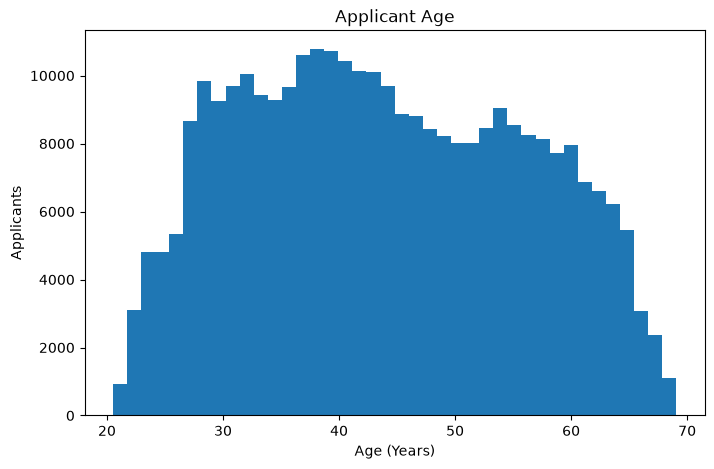

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    feature_df["AGE_YEARS"],
    bins=40
)

plt.xlabel("Age (Years)")
plt.ylabel("Applicants")
plt.title("Applicant Age")

plt.show()

Employment years

In [12]:
feature_df["EMPLOYMENT_YEARS"] = (
    -feature_df["DAYS_EMPLOYED_CLEAN"]
    / 365.25
)

In [13]:
feature_df["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.527500
std           6.402081
min          -0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64

Employment-to-age ratio

In [14]:
feature_df["EMPLOYMENT_AGE_RATIO"] = (
    feature_df["EMPLOYMENT_YEARS"]
    / feature_df["AGE_YEARS"]
)

In [15]:
feature_df["EMPLOYMENT_AGE_RATIO"].describe()

count    252137.000000
mean          0.156861
std           0.133549
min          -0.000000
25%           0.056099
50%           0.118733
75%           0.219170
max           0.728811
Name: EMPLOYMENT_AGE_RATIO, dtype: float64

How much of the applicant's lifetime
has been spent in their current employment history

Credit-to-income ratio

In [16]:
feature_df["CREDIT_INCOME_RATIO"] = (
    feature_df["AMT_CREDIT"]
    / feature_df["AMT_INCOME_TOTAL"]
)

₹500K credit / ₹100K income = 5.0
₹500K credit / ₹500K income = 1.0

Same loan, very different burden

In [17]:
feature_df.groupby("TARGET")[
    "CREDIT_INCOME_RATIO"
].median()

TARGET
0    3.266653
1    3.253143
Name: CREDIT_INCOME_RATIO, dtype: float64

Annuity-to-income ratio

In [18]:
feature_df["ANNUITY_INCOME_RATIO"] = (
    feature_df["AMT_ANNUITY"]
    / feature_df["AMT_INCOME_TOTAL"]
)

This approximates repayment burden relative to income

In [19]:
feature_df.groupby("TARGET")[
    "ANNUITY_INCOME_RATIO"
].median()

TARGET
0    0.162280
1    0.169294
Name: ANNUITY_INCOME_RATIO, dtype: float64

Credit-to-annuity ratio

In [20]:
feature_df["CREDIT_ANNUITY_RATIO"] = (
    feature_df["AMT_CREDIT"]
    / feature_df["AMT_ANNUITY"]
)

This gives a rough representation of the loan repayment horizon

In [21]:
feature_df[
    "CREDIT_ANNUITY_RATIO"
].describe()

count    307499.000000
mean         21.612322
std           7.823823
min           8.036674
25%          15.614496
50%          20.000000
75%          27.099985
max          45.305079
Name: CREDIT_ANNUITY_RATIO, dtype: float64

Goods-price relationship

In [22]:
feature_df["CREDIT_GOODS_RATIO"] = (
    feature_df["AMT_CREDIT"]
    / feature_df["AMT_GOODS_PRICE"]
)

This can capture how much financing is being used relative to the underlying purchase.

Income per family member

In [23]:
feature_df["INCOME_PER_PERSON"] = (
    feature_df["AMT_INCOME_TOTAL"]
    / feature_df["CNT_FAM_MEMBERS"]
)

In [24]:
feature_df["CREDIT_PER_PERSON"] = (
    feature_df["AMT_CREDIT"]
    / feature_df["CNT_FAM_MEMBERS"]
)

In [25]:
feature_df["ANNUITY_PER_PERSON"] = (
    feature_df["AMT_ANNUITY"]
    / feature_df["CNT_FAM_MEMBERS"]
)

Children to Family Ratio


In [26]:
feature_df["CHILDREN_FAMILY_RATIO"] = (
    feature_df["CNT_CHILDREN"]
    / feature_df["CNT_FAM_MEMBERS"]
)

External credit-score features

In [27]:
external_columns = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

In [28]:
feature_df["EXT_SOURCE_MEAN"] = (
    feature_df[external_columns]
    .mean(axis=1)
)

In [29]:
feature_df["EXT_SOURCE_MIN"] = (
    feature_df[external_columns]
    .min(axis=1)
)

In [30]:
feature_df["EXT_SOURCE_MAX"] = (
    feature_df[external_columns]
    .max(axis=1)
)

In [31]:
feature_df["EXT_SOURCE_STD"] = (
    feature_df[external_columns]
    .std(axis=1)
)

In [32]:
feature_df.groupby("TARGET")[
    [
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_MIN",
        "EXT_SOURCE_MAX",
        "EXT_SOURCE_STD"
    ]
].mean()

,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_STD
TARGET,,,,
0,0.519109,0.409872,0.624991,0.149857
1,0.397003,0.282408,0.512156,0.167606


Number of external scores available

In [33]:
feature_df["EXT_SOURCE_COUNT"] = (
    feature_df[external_columns]
    .notna()
    .sum(axis=1)
)

In [34]:
feature_df[
    "EXT_SOURCE_COUNT"
].value_counts().sort_index()

EXT_SOURCE_COUNT
0       172
1     36737
2    161013
3    109589
Name: count, dtype: int64

In [35]:
feature_df.groupby(
    "EXT_SOURCE_COUNT"
)["TARGET"].mean().mul(100)

EXT_SOURCE_COUNT
0    8.139535
1    9.921877
2    8.178222
3    7.298178
Name: TARGET, dtype: float64

Document-count features

Home Credit includes columns such as:

FLAG_DOCUMENT_2
FLAG_DOCUMENT_3
...
FLAG_DOCUMENT_21

In [36]:
document_columns = [
    column
    for column in feature_df.columns
    if column.startswith("FLAG_DOCUMENT_")
]

len(document_columns)

20

In [37]:
feature_df["DOCUMENT_COUNT"] = (
    feature_df[document_columns]
    .sum(axis=1)
)

In [38]:
feature_df[
    "DOCUMENT_COUNT"
].value_counts().sort_index()

DOCUMENT_COUNT
0     29549
1    270056
2      7742
3       163
4         1
Name: count, dtype: int64

## Contact-information count

There are also fields like:

FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
FLAG_EMAIL

In [39]:
contact_columns = [
    "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL"
]

In [40]:
feature_df["CONTACT_COUNT"] = (
    feature_df[contact_columns]
    .sum(axis=1)
)

In [41]:
feature_df.groupby(
    "CONTACT_COUNT"
)["TARGET"].mean().mul(100)

CONTACT_COUNT
1    3.703704
2    5.665198
3    8.379718
4    8.497120
5    8.390623
6    8.985944
Name: TARGET, dtype: float64

## Social-circle risk features

There are features such as:

OBS_30_CNT_SOCIAL_CIRCLE
DEF_30_CNT_SOCIAL_CIRCLE

In [42]:
feature_df["DEF_30_SOCIAL_RATIO"] = (
    feature_df["DEF_30_CNT_SOCIAL_CIRCLE"]
    / feature_df["OBS_30_CNT_SOCIAL_CIRCLE"]
)

In [43]:
feature_df["DEF_60_SOCIAL_RATIO"] = (
    feature_df["DEF_60_CNT_SOCIAL_CIRCLE"]
    / feature_df["OBS_60_CNT_SOCIAL_CIRCLE"]
)

Replace infinities

In [44]:
feature_df = feature_df.replace(
    [np.inf, -np.inf],
    np.nan
)

In [45]:
np.isinf(
    feature_df.select_dtypes(
        include=np.number
    )
).sum().sum()

np.int64(0)

Collect our engineered features

In [46]:
engineered_features = [
    "DAYS_EMPLOYED_ANOMALY",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_AGE_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "CREDIT_GOODS_RATIO",
    "INCOME_PER_PERSON",
    "CREDIT_PER_PERSON",
    "ANNUITY_PER_PERSON",
    "CHILDREN_FAMILY_RATIO",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_STD",
    "EXT_SOURCE_COUNT",
    "DOCUMENT_COUNT",
    "CONTACT_COUNT",
    "DEF_30_SOCIAL_RATIO",
    "DEF_60_SOCIAL_RATIO"
]

In [47]:
feature_df[
    engineered_features
].head()

,DAYS_EMPLOYED_ANOMALY,AGE_YEARS,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,CREDIT_PER_PERSON,ANNUITY_PER_PERSON,CHILDREN_FAMILY_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_STD,EXT_SOURCE_COUNT,DOCUMENT_COUNT,CONTACT_COUNT,DEF_30_SOCIAL_RATIO,DEF_60_SOCIAL_RATIO
0,0,25.902806,1.744011,0.067329,2.007889,0.121978,16.461104,1.158397,202500.0,406597.50,24700.50,0.0,0.161787,0.083037,0.262949,0.092026,3,1,4,1.0,1.0
1,0,45.900068,3.252567,0.070862,4.790750,0.132217,36.234085,1.145199,135000.0,646751.25,17849.25,0.0,0.466757,0.311267,0.622246,0.219895,2,1,4,0.0,0.0
2,0,52.145106,0.616016,0.011814,2.000000,0.100000,20.000000,1.000000,67500.0,135000.00,6750.00,0.0,0.642739,0.555912,0.729567,0.122792,2,0,5,NaN,NaN
3,0,52.032854,8.320329,0.159905,2.316167,0.219900,10.532818,1.052803,67500.0,156341.25,14843.25,0.0,0.650442,0.650442,0.650442,NaN,1,1,3,0.0,0.0
4,0,54.570842,8.317591,0.152418,4.222222,0.179963,23.461618,1.000000,121500.0,513000.00,21865.50,0.0,0.322738,0.322738,0.322738,NaN,1,1,3,NaN,NaN


Missingness in engineered features

In [48]:
engineered_missing = (
    feature_df[
        engineered_features
    ]
    .isna()
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
)

engineered_missing

DEF_60_SOCIAL_RATIO      53.880024
DEF_30_SOCIAL_RATIO      53.634179
EMPLOYMENT_YEARS         18.007161
EMPLOYMENT_AGE_RATIO     18.007161
EXT_SOURCE_STD           12.002497
CREDIT_GOODS_RATIO        0.090403
EXT_SOURCE_MIN            0.055933
EXT_SOURCE_MAX            0.055933
EXT_SOURCE_MEAN           0.055933
ANNUITY_PER_PERSON        0.004553
ANNUITY_INCOME_RATIO      0.003902
CREDIT_ANNUITY_RATIO      0.003902
INCOME_PER_PERSON         0.000650
CHILDREN_FAMILY_RATIO     0.000650
CREDIT_PER_PERSON         0.000650
DAYS_EMPLOYED_ANOMALY     0.000000
AGE_YEARS                 0.000000
CREDIT_INCOME_RATIO       0.000000
EXT_SOURCE_COUNT          0.000000
CONTACT_COUNT             0.000000
DOCUMENT_COUNT            0.000000
dtype: float64

Compare target groups

In [49]:
feature_target_summary = (
    feature_df
    .groupby("TARGET")[
        engineered_features
    ]
    .median()
    .T
)

feature_target_summary.columns = [
    "Non_Default_Median",
    "Payment_Difficulty_Median"
]

feature_target_summary

,Non_Default_Median,Payment_Difficulty_Median
DAYS_EMPLOYED_ANOMALY,0.000000,0.000000
AGE_YEARS,43.468857,39.101985
EMPLOYMENT_YEARS,4.629706,3.367556
EMPLOYMENT_AGE_RATIO,0.121592,0.093461
CREDIT_INCOME_RATIO,3.266653,3.253143
ANNUITY_INCOME_RATIO,0.162280,0.169294
CREDIT_ANNUITY_RATIO,20.000000,20.000000
CREDIT_GOODS_RATIO,1.118800,1.145200
INCOME_PER_PERSON,75000.000000,70500.000000
CREDIT_PER_PERSON,256765.500000,243000.000000


Measure individual numeric predictive signal

In [50]:
feature_auc_results = []

for feature in engineered_features:

    temp = feature_df[
        [feature, "TARGET"]
    ].dropna()

    if (
        temp.empty
        or temp[feature].nunique() <= 1
    ):
        continue

    auc = roc_auc_score(
        temp["TARGET"],
        temp[feature]
    )

    signal_auc = max(
        auc,
        1 - auc
    )

    feature_auc_results.append(
        {
            "feature": feature,
            "raw_auc": auc,
            "signal_auc": signal_auc,
        }
    )

In [51]:
feature_auc_df = (
    pd.DataFrame(
        feature_auc_results
    )
    .sort_values(
        "signal_auc",
        ascending=False
    )
)

feature_auc_df

,feature,raw_auc,signal_auc
12,EXT_SOURCE_MEAN,0.283465,0.716535
13,EXT_SOURCE_MIN,0.308984,0.691016
14,EXT_SOURCE_MAX,0.313828,0.686172
1,AGE_YEARS,0.416997,0.583003
2,EMPLOYMENT_YEARS,0.417609,0.582391
3,EMPLOYMENT_AGE_RATIO,0.430304,0.569696
7,CREDIT_GOODS_RATIO,0.569198,0.569198
15,EXT_SOURCE_STD,0.548556,0.548556
19,DEF_30_SOCIAL_RATIO,0.536463,0.536463
0,DAYS_EMPLOYED_ANOMALY,0.467568,0.532432


Signal AUC ≈ 0.50
→ almost no standalone ranking power

0.55+
→ some signal

0.60+
→ meaningful standalone signal

0.70+
→ very strong standalone feature

Plot feature signal

In [52]:
top_feature_auc = (
    feature_auc_df
    .head(15)
    .sort_values(
        "signal_auc"
    )
)

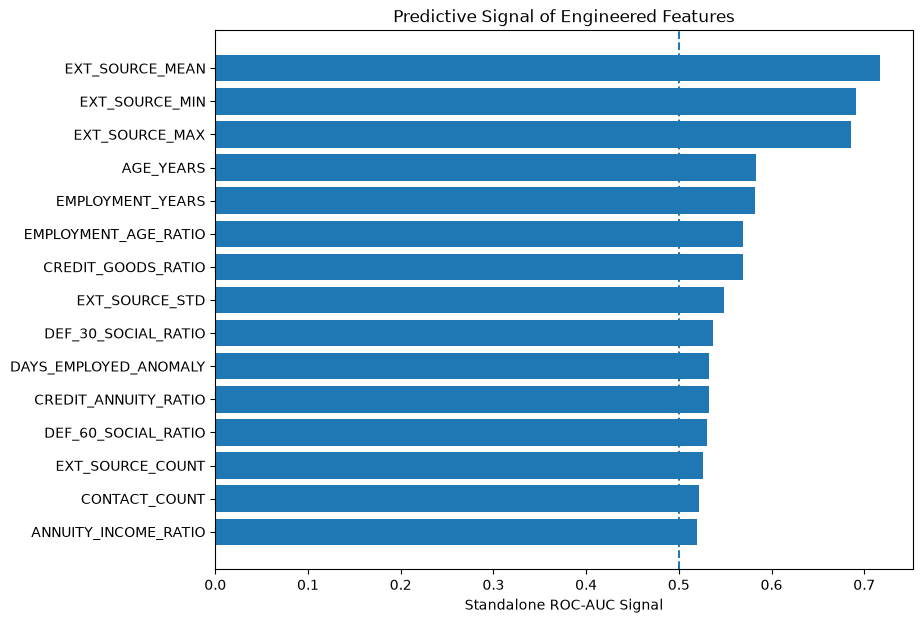

In [53]:
plt.figure(figsize=(9, 7))

plt.barh(
    top_feature_auc["feature"],
    top_feature_auc["signal_auc"]
)

plt.axvline(
    0.5,
    linestyle="--"
)

plt.xlabel("Standalone ROC-AUC Signal")
plt.title(
    "Predictive Signal of Engineered Features"
)

plt.show()

Compare raw vs engineered versions

In [54]:
comparison_features = [
    "DAYS_BIRTH",
    "AGE_YEARS",

    "DAYS_EMPLOYED_CLEAN",
    "EMPLOYMENT_YEARS",

    "AMT_CREDIT",
    "CREDIT_INCOME_RATIO",

    "AMT_ANNUITY",
    "ANNUITY_INCOME_RATIO",

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN"
]

In [55]:
comparison_results = []

for feature in comparison_features:

    temp = feature_df[
        [feature, "TARGET"]
    ].dropna()

    if temp[feature].nunique() <= 1:
        continue

    auc = roc_auc_score(
        temp["TARGET"],
        temp[feature]
    )

    comparison_results.append(
        {
            "feature": feature,
            "signal_auc": max(
                auc,
                1 - auc
            )
        }
    )

In [56]:
pd.DataFrame(
    comparison_results
).sort_values(
    "signal_auc",
    ascending=False
)

,feature,signal_auc
11,EXT_SOURCE_MEAN,0.716535
10,EXT_SOURCE_3,0.679400
8,EXT_SOURCE_1,0.665681
9,EXT_SOURCE_2,0.656120
1,AGE_YEARS,0.583003
0,DAYS_BIRTH,0.583003
3,EMPLOYMENT_YEARS,0.582391
2,DAYS_EMPLOYED_CLEAN,0.582391
7,ANNUITY_INCOME_RATIO,0.519531
4,AMT_CREDIT,0.518582


Look for Extreme Engineered Values

In [57]:
feature_df[
    engineered_features
].describe(
    percentiles=[
        0.01,
        0.50,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,1%,50%,95%,99%,max
DAYS_EMPLOYED_ANOMALY,307511.0,0.180072,0.384248,0.000000e+00,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00
AGE_YEARS,307511.0,43.906900,11.947950,2.050376e+01,22.622861,43.121150,63.529090,6.685558e+01,6.907324e+01
EMPLOYMENT_YEARS,252137.0,6.527500,6.402081,-0.000000e+00,0.303901,4.511978,19.961670,3.104252e+01,4.904038e+01
EMPLOYMENT_AGE_RATIO,252137.0,0.156861,0.133549,-0.000000e+00,0.007548,0.118733,0.442200,5.906004e-01,7.288115e-01
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,4.807615e-03,0.595365,3.265067,9.156739,1.302728e+01,8.473684e+01
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,2.238846e-04,0.039474,0.162833,0.354667,4.834585e-01,1.875965e+00
CREDIT_ANNUITY_RATIO,307499.0,21.612322,7.823823,8.036674e+00,8.709985,20.000000,34.542314,3.779412e+01,4.530508e+01
CREDIT_GOODS_RATIO,307233.0,1.122995,0.124045,1.500000e-01,1.000000,1.118800,1.396000,1.475200e+00,6.000000e+00
INCOME_PER_PERSON,307509.0,93105.879645,101373.363394,2.812500e+03,18000.000000,75000.000000,225000.000000,3.375000e+05,3.900000e+07
CREDIT_PER_PERSON,307509.0,323949.587662,259087.050339,6.750000e+03,33750.000000,255051.000000,808650.000000,1.258650e+06,4.031032e+06


Check feature correlations

In [58]:
engineered_corr = (
    feature_df[
        engineered_features
    ]
    .corr()
    .abs()
)

Find highly correlated features

In [59]:
upper = engineered_corr.where(
    np.triu(
        np.ones(
            engineered_corr.shape
        ),
        k=1
    ).astype(bool)
)

In [60]:
high_corr_pairs = []

for column in upper.columns:

    matches = upper[column][
        upper[column] > 0.90
    ]

    for feature, correlation in matches.items():

        high_corr_pairs.append(
            {
                "feature_1": feature,
                "feature_2": column,
                "correlation": correlation
            }
        )

In [61]:
pd.DataFrame(
    high_corr_pairs
).sort_values(
    "correlation",
    ascending=False
)

,feature_1,feature_2,correlation
0,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO,0.954679


## Don't drop the original features

We're adding:

CREDIT_INCOME_RATIO

but we aren't necessarily removing:

AMT_CREDIT
AMT_INCOME_TOTAL

The model may benefit from having all three.

Create the candidate feature-engineering function

In [62]:
def create_features(df):

    df = df.copy()

    # Employment anomaly
    df["DAYS_EMPLOYED_ANOMALY"] = (
        df["DAYS_EMPLOYED"] == 365243
    ).astype(int)

    df["DAYS_EMPLOYED_CLEAN"] = (
        df["DAYS_EMPLOYED"]
        .replace(
            365243,
            np.nan
        )
    )

    # Age and employment
    df["AGE_YEARS"] = (
        -df["DAYS_BIRTH"]
        / 365.25
    )

    df["EMPLOYMENT_YEARS"] = (
        -df["DAYS_EMPLOYED_CLEAN"]
        / 365.25
    )

    df["EMPLOYMENT_AGE_RATIO"] = (
        df["EMPLOYMENT_YEARS"]
        / df["AGE_YEARS"]
    )

    # Affordability
    df["CREDIT_INCOME_RATIO"] = (
        df["AMT_CREDIT"]
        / df["AMT_INCOME_TOTAL"]
    )

    df["ANNUITY_INCOME_RATIO"] = (
        df["AMT_ANNUITY"]
        / df["AMT_INCOME_TOTAL"]
    )

    df["CREDIT_ANNUITY_RATIO"] = (
        df["AMT_CREDIT"]
        / df["AMT_ANNUITY"]
    )

    df["CREDIT_GOODS_RATIO"] = (
        df["AMT_CREDIT"]
        / df["AMT_GOODS_PRICE"]
    )

    # Household
    df["INCOME_PER_PERSON"] = (
        df["AMT_INCOME_TOTAL"]
        / df["CNT_FAM_MEMBERS"]
    )

    df["CREDIT_PER_PERSON"] = (
        df["AMT_CREDIT"]
        / df["CNT_FAM_MEMBERS"]
    )

    df["ANNUITY_PER_PERSON"] = (
        df["AMT_ANNUITY"]
        / df["CNT_FAM_MEMBERS"]
    )

    df["CHILDREN_FAMILY_RATIO"] = (
        df["CNT_CHILDREN"]
        / df["CNT_FAM_MEMBERS"]
    )

    # External scores
    external_columns = [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]

    df["EXT_SOURCE_MEAN"] = (
        df[external_columns]
        .mean(axis=1)
    )

    df["EXT_SOURCE_MIN"] = (
        df[external_columns]
        .min(axis=1)
    )

    df["EXT_SOURCE_MAX"] = (
        df[external_columns]
        .max(axis=1)
    )

    df["EXT_SOURCE_STD"] = (
        df[external_columns]
        .std(axis=1)
    )

    df["EXT_SOURCE_COUNT"] = (
        df[external_columns]
        .notna()
        .sum(axis=1)
    )

    # Documents
    document_columns = [
        column
        for column in df.columns
        if column.startswith(
            "FLAG_DOCUMENT_"
        )
    ]

    df["DOCUMENT_COUNT"] = (
        df[document_columns]
        .sum(axis=1)
    )

    # Contact information
    contact_columns = [
        "FLAG_MOBIL",
        "FLAG_EMP_PHONE",
        "FLAG_WORK_PHONE",
        "FLAG_CONT_MOBILE",
        "FLAG_PHONE",
        "FLAG_EMAIL"
    ]

    df["CONTACT_COUNT"] = (
        df[contact_columns]
        .sum(axis=1)
    )

    # Social-circle risk
    df["DEF_30_SOCIAL_RATIO"] = (
        df["DEF_30_CNT_SOCIAL_CIRCLE"]
        / df["OBS_30_CNT_SOCIAL_CIRCLE"]
    )

    df["DEF_60_SOCIAL_RATIO"] = (
        df["DEF_60_CNT_SOCIAL_CIRCLE"]
        / df["OBS_60_CNT_SOCIAL_CIRCLE"]
    )

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return df

Test the function

In [63]:
test_features = create_features(
    df.head(100)
)

test_features.shape

(100, 144)

In [64]:
set(
    engineered_features
).issubset(
    test_features.columns
)

True

Verify the original dataframe wasn't mutated

In [65]:
"CREDIT_INCOME_RATIO" in df.columns

False

## Feature Engineering Findings

The feature-engineering stage produced several interpretable groups of candidate predictors.

### Applicant stability

- `AGE_YEARS`
- `EMPLOYMENT_YEARS`
- `EMPLOYMENT_AGE_RATIO`
- `DAYS_EMPLOYED_ANOMALY`

### Financial burden

- `CREDIT_INCOME_RATIO`
- `ANNUITY_INCOME_RATIO`
- `CREDIT_ANNUITY_RATIO`
- `CREDIT_GOODS_RATIO`

### Household affordability

- `INCOME_PER_PERSON`
- `CREDIT_PER_PERSON`
- `ANNUITY_PER_PERSON`
- `CHILDREN_FAMILY_RATIO`

### External credit information

- `EXT_SOURCE_MEAN`
- `EXT_SOURCE_MIN`
- `EXT_SOURCE_MAX`
- `EXT_SOURCE_STD`
- `EXT_SOURCE_COUNT`

### Behavioural / application features

- `DOCUMENT_COUNT`
- `CONTACT_COUNT`
- `DEF_30_SOCIAL_RATIO`
- `DEF_60_SOCIAL_RATIO`

Standalone ROC-AUC analysis was used to compare the discriminatory signal of candidate features.

These features will now be evaluated jointly within predictive models rather than selected solely from univariate statistics.

## Feature Engineering Findings

The feature-engineering stage produced several interpretable groups of candidate predictors.

### Applicant stability

- `AGE_YEARS`
- `EMPLOYMENT_YEARS`
- `EMPLOYMENT_AGE_RATIO`
- `DAYS_EMPLOYED_ANOMALY`

### Financial burden

- `CREDIT_INCOME_RATIO`
- `ANNUITY_INCOME_RATIO`
- `CREDIT_ANNUITY_RATIO`
- `CREDIT_GOODS_RATIO`

### Household affordability

- `INCOME_PER_PERSON`
- `CREDIT_PER_PERSON`
- `ANNUITY_PER_PERSON`
- `CHILDREN_FAMILY_RATIO`

### External credit information

- `EXT_SOURCE_MEAN`
- `EXT_SOURCE_MIN`
- `EXT_SOURCE_MAX`
- `EXT_SOURCE_STD`
- `EXT_SOURCE_COUNT`

### Behavioural / application features

- `DOCUMENT_COUNT`
- `CONTACT_COUNT`
- `DEF_30_SOCIAL_RATIO`
- `DEF_60_SOCIAL_RATIO`

Standalone ROC-AUC analysis was used to compare the discriminatory signal of candidate features.

These features will now be evaluated jointly within predictive models rather than selected solely from univariate statistics.